In [17]:
# ============================================================
# AAI-510 Final Project
# Student Performance Exploratory Data Analysis
# Dataset: Student Performance Dataset from Kaggle
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Student_performance_data _.csv')

# Display the first few rows
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [18]:
# Check the size of the dataset
print("Dataset Shape:", df.shape)

# Display column names
print("Column Names:")
print(df.columns)

Dataset Shape: (2392, 15)
Column Names:
Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [19]:
# View summary statistics for numerical variables
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [20]:
# Check for missing values
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [21]:
# Display data types
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

In [22]:
# Dropping StudentID because it is only an identifier and does not help prediction
df = df.drop(columns=["StudentID"])

# Confirm the column was removed
df.head()

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [23]:
# Rename GradeClass values for easier interpretation

grade_mapping = {
    0.0: "A",
    1.0: "B",
    2.0: "C",
    3.0: "D",
    4.0: "F"
}

df["GradeClassLabel"] = df["GradeClass"].map(grade_mapping)

# Check class distribution
df["GradeClassLabel"].value_counts()

F    1211
D     414
C     391
B     269
A     107
Name: GradeClassLabel, dtype: int64

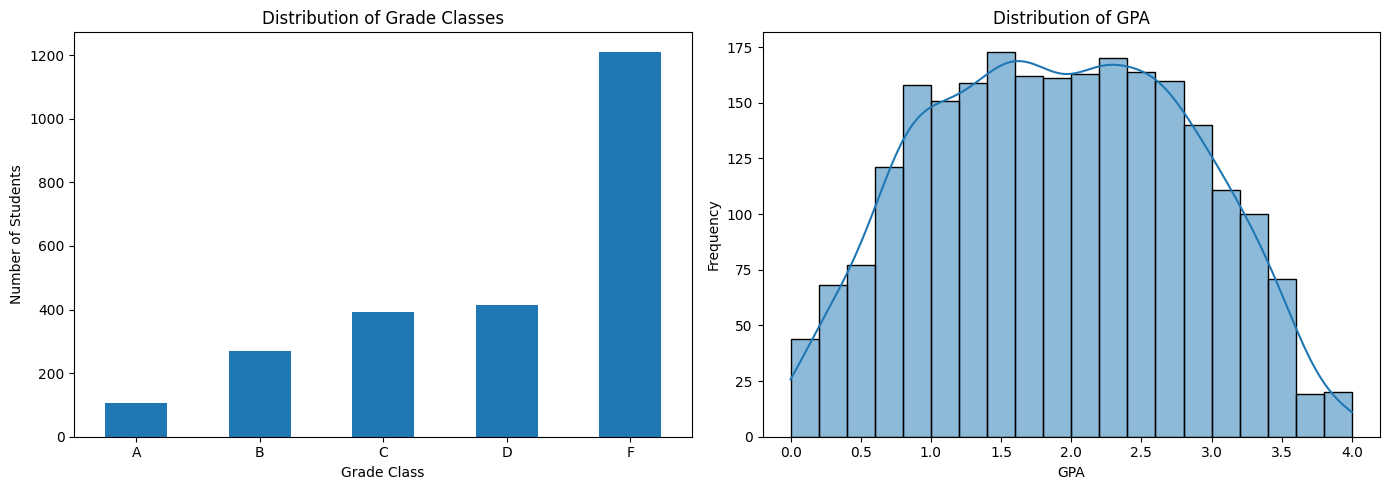

In [24]:
# Grade Class and GPA Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grade Class Distribution
df["GradeClassLabel"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Distribution of Grade Classes")
axes[0].set_xlabel("Grade Class")
axes[0].set_ylabel("Number of Students")
axes[0].tick_params(axis='x', rotation=0)

# GPA KDE Histogram
sns.histplot(
    data=df,
    x="GPA",
    kde=True,
    bins=20,
    ax=axes[1]
)

axes[1].set_title("Distribution of GPA")
axes[1].set_xlabel("GPA")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

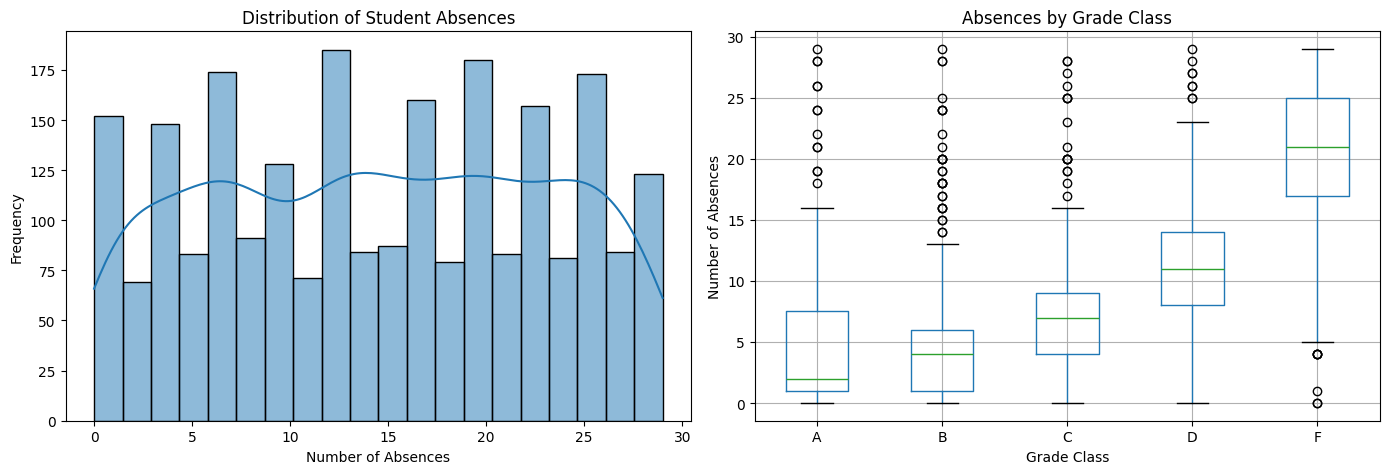

In [27]:
# Absences Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE Histogram
sns.histplot(
    data=df,
    x="Absences",
    kde=True,
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Distribution of Student Absences")
axes[0].set_xlabel("Number of Absences")
axes[0].set_ylabel("Frequency")

# Absences by Grade Class
df.boxplot(
    column="Absences",
    by="GradeClassLabel",
    ax=axes[1]
)

axes[1].set_title("Absences by Grade Class")
axes[1].set_xlabel("Grade Class")
axes[1].set_ylabel("Number of Absences")

# Remove automatic pandas title
plt.suptitle("")

plt.tight_layout()
plt.show()

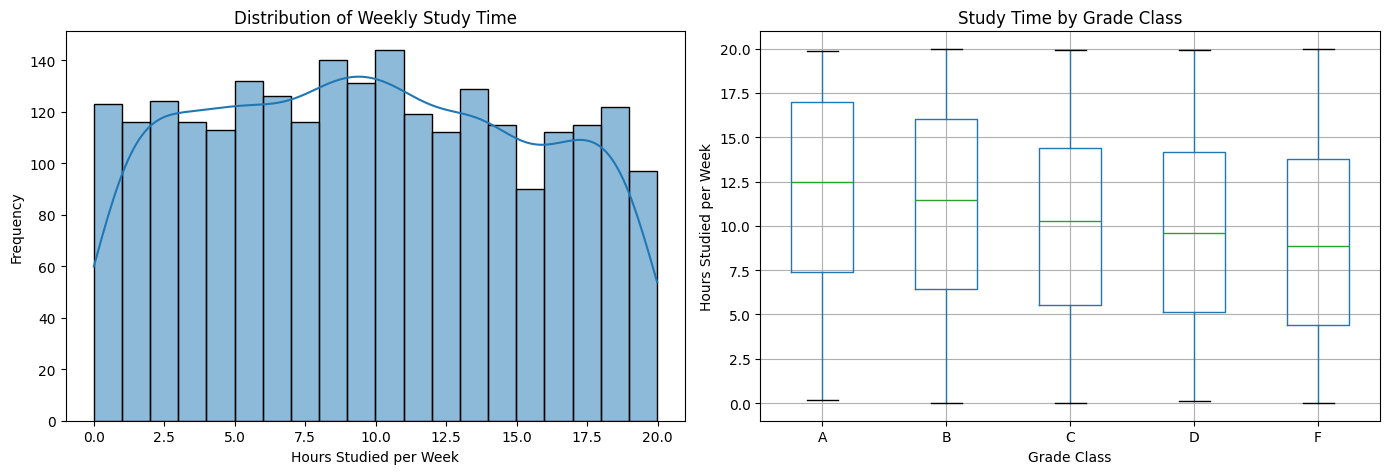

In [28]:
# Study Time Distribution and Study Time by Grade Class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE Histogram
sns.histplot(
    data=df,
    x="StudyTimeWeekly",
    kde=True,
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Distribution of Weekly Study Time")
axes[0].set_xlabel("Hours Studied per Week")
axes[0].set_ylabel("Frequency")

# Study Time by Grade Class
df.boxplot(
    column="StudyTimeWeekly",
    by="GradeClassLabel",
    ax=axes[1]
)

axes[1].set_title("Study Time by Grade Class")
axes[1].set_xlabel("Grade Class")
axes[1].set_ylabel("Hours Studied per Week")

plt.suptitle("")
plt.tight_layout()
plt.show()

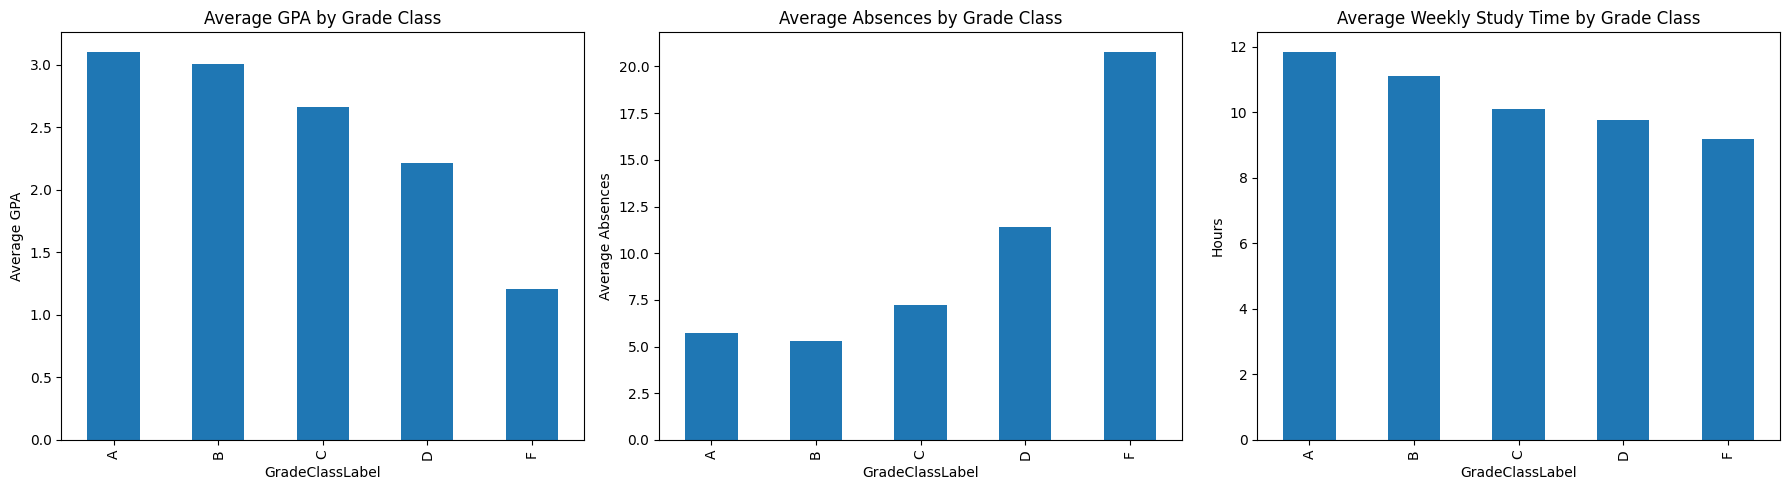

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# GPA
df.groupby("GradeClassLabel")["GPA"].mean().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_title("Average GPA by Grade Class")
axes[0].set_ylabel("Average GPA")

# Absences
df.groupby("GradeClassLabel")["Absences"].mean().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_title("Average Absences by Grade Class")
axes[1].set_ylabel("Average Absences")

# Study Time
df.groupby("GradeClassLabel")["StudyTimeWeekly"].mean().plot(
    kind="bar",
    ax=axes[2]
)
axes[2].set_title("Average Weekly Study Time by Grade Class")
axes[2].set_ylabel("Hours")

plt.tight_layout()
plt.show()

Students receiving A and B grades generally exhibit higher GPAs, fewer absences, and greater weekly study time than students receiving D and F grades. These findings suggest that attendance and study habits may be important predictors of academic performance and should be considered during model development.

In [30]:
# Correlation matrix
correlation_matrix = df.drop(columns=["GradeClassLabel"]).corr()

correlation_matrix

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
Age,1.000000,0.044895,-0.028473,0.025099,-0.006800,-0.011511,-0.012076,0.033197,-0.025061,-0.046320,-0.003492,0.013074,0.000275,-0.006250
Gender,0.044895,1.000000,0.016010,0.006771,0.011469,0.021479,-0.031597,0.008065,-0.005964,-0.008897,0.007109,-0.000200,-0.013360,0.022998
Ethnicity,-0.028473,0.016010,1.000000,0.033595,0.007184,-0.025712,-0.017440,0.020922,-0.008927,-0.004484,-0.014627,0.013468,0.027760,-0.023326
ParentalEducation,0.025099,0.006771,0.033595,1.000000,-0.011051,0.036518,-0.017340,-0.017463,0.007479,0.002029,0.039439,0.011960,-0.035854,0.041031
StudyTimeWeekly,-0.006800,0.011469,0.007184,-0.011051,1.000000,0.009326,0.028930,0.035800,-0.022860,0.006836,0.007791,-0.016604,0.179275,-0.134131
Absences,-0.011511,0.021479,-0.025712,0.036518,0.009326,1.000000,-0.015534,0.002108,0.000360,0.041454,-0.008692,-0.018528,-0.919314,0.728633
Tutoring,-0.012076,-0.031597,-0.017440,-0.017340,0.028930,-0.015534,1.000000,-0.000824,0.004865,0.006278,-0.011385,-0.050898,0.145119,-0.111695
ParentalSupport,0.033197,0.008065,0.020922,-0.017463,0.035800,0.002108,-0.000824,1.000000,-0.008381,-0.006176,0.035122,-0.006036,0.190774,-0.136823
Extracurricular,-0.025061,-0.005964,-0.008927,0.007479,-0.022860,0.000360,0.004865,-0.008381,1.000000,-0.011820,-0.014191,-0.007427,0.094078,-0.069733
Sports,-0.046320,-0.008897,-0.004484,0.002029,0.006836,0.041454,0.006278,-0.006176,-0.011820,1.000000,-0.020474,-0.002799,0.057859,-0.026654


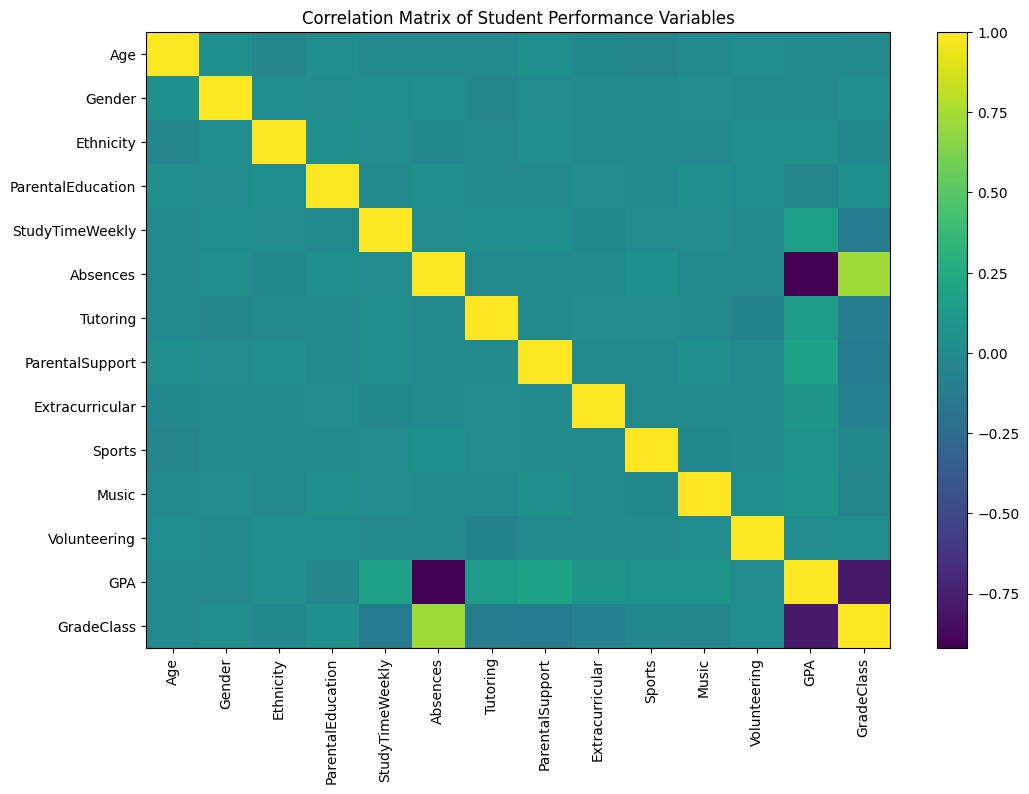

In [31]:
# Visualize correlation matrix
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Student Performance Variables")
plt.show()

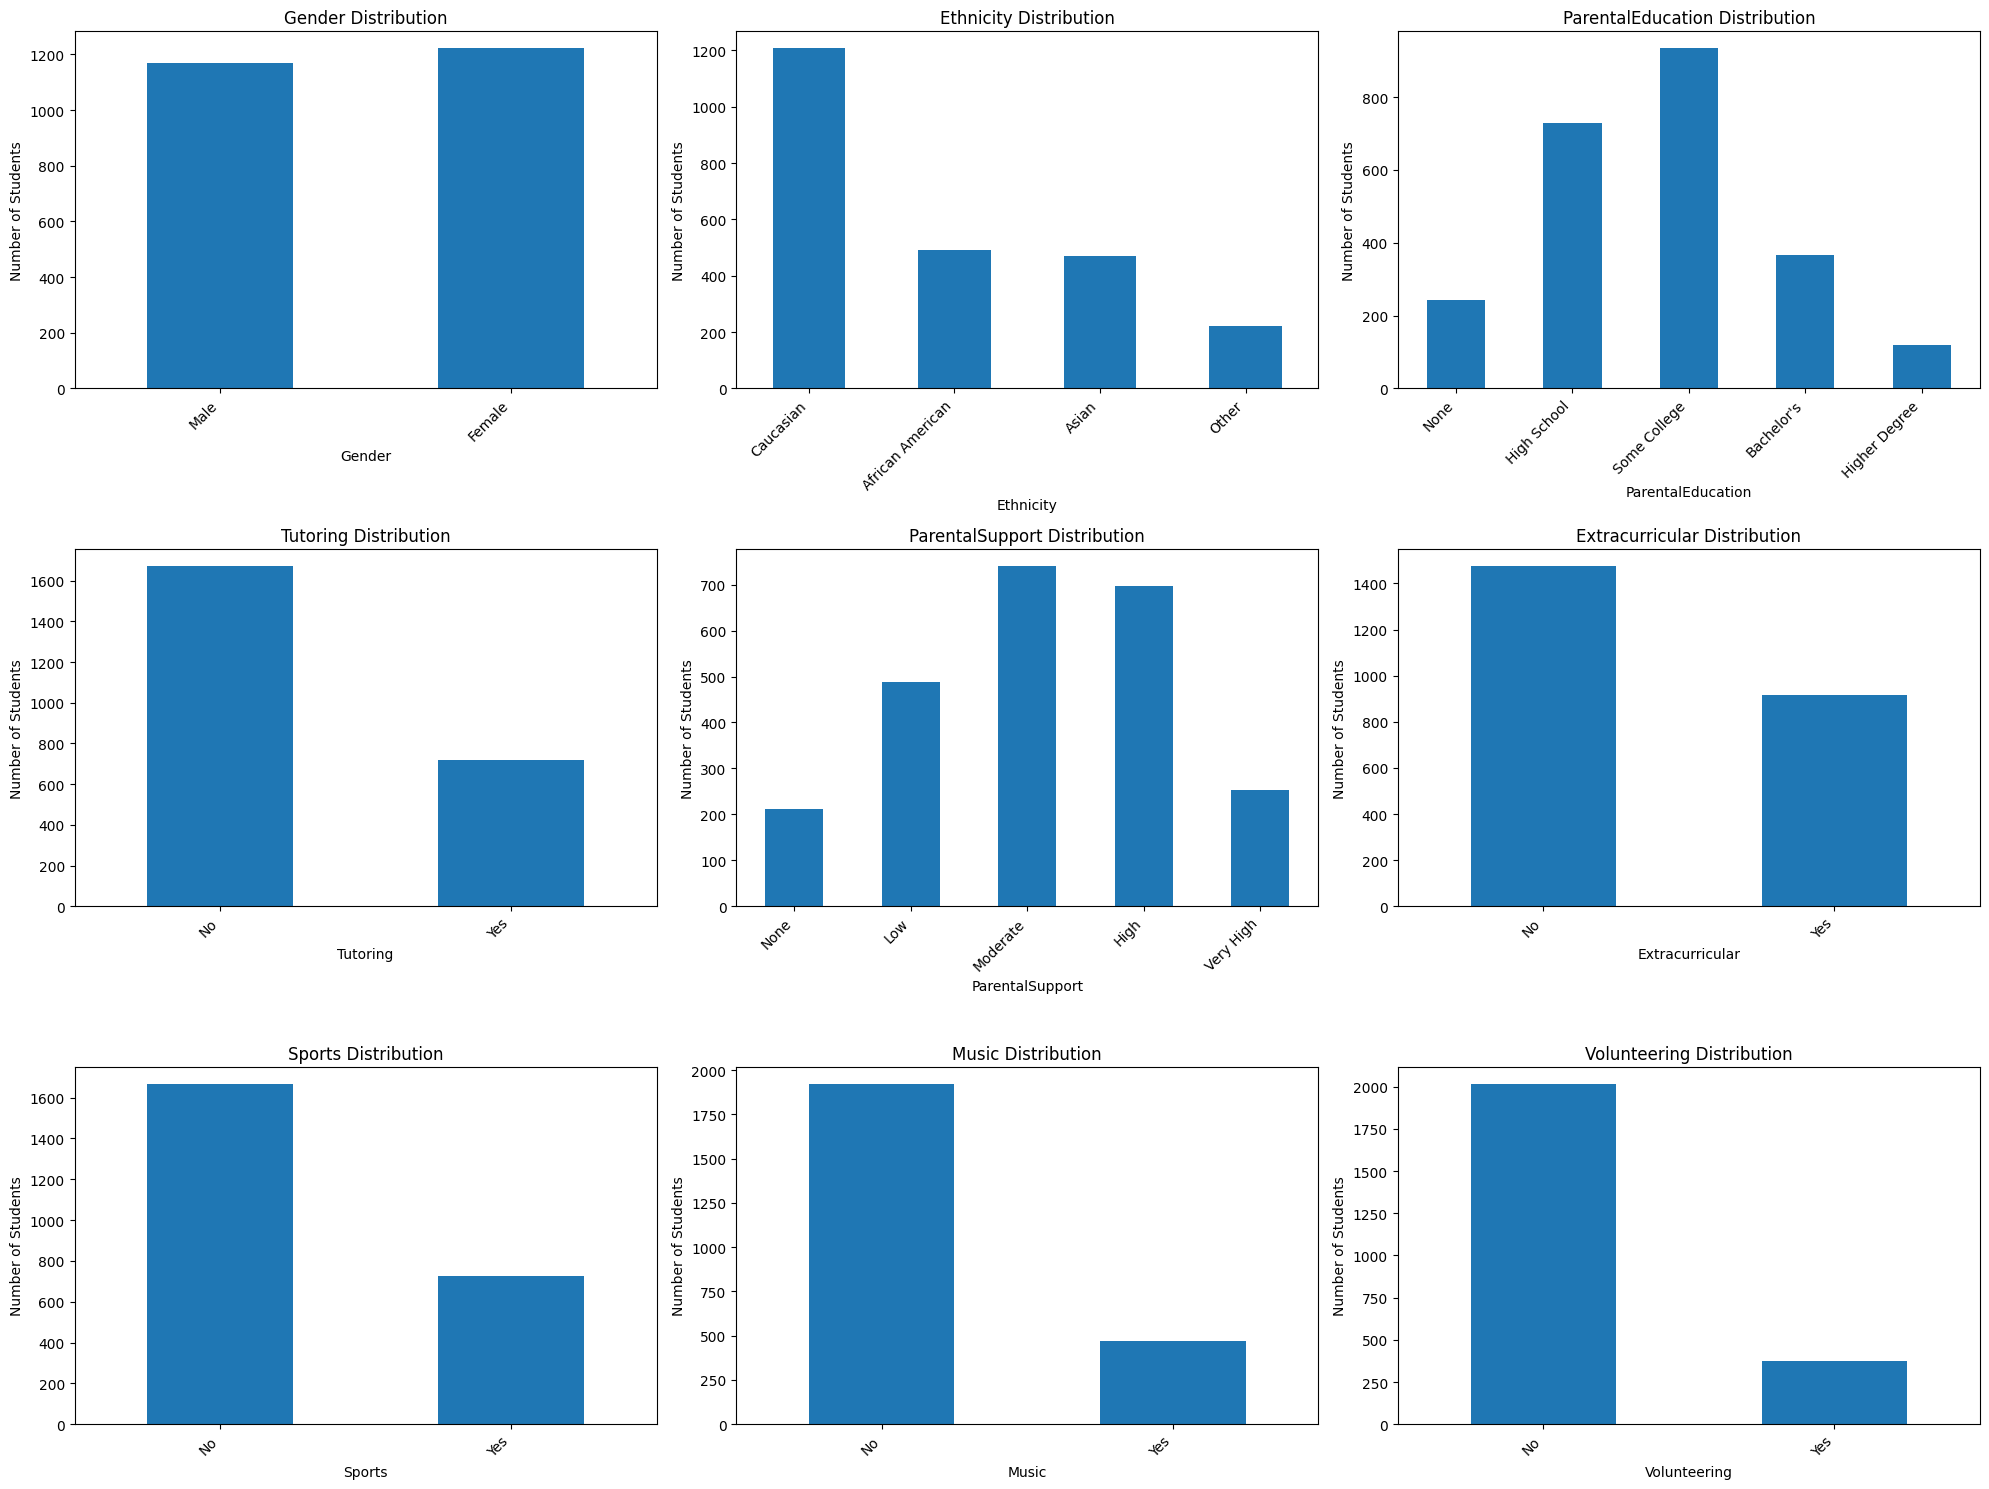

In [37]:
# Categorical Feature Distributions

categorical_columns = [
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering"
]

# Label mappings
label_maps = {
    "Gender": {
        0: "Male",
        1: "Female"
    },

    "Ethnicity": {
        0: "Caucasian",
        1: "African American",
        2: "Asian",
        3: "Other"
    },

    "ParentalEducation": {
        0: "None",
        1: "High School",
        2: "Some College",
        3: "Bachelor's",
        4: "Higher Degree"
    },

    "Tutoring": {
        0: "No",
        1: "Yes"
    },

    "ParentalSupport": {
        0: "None",
        1: "Low",
        2: "Moderate",
        3: "High",
        4: "Very High"
    },

    "Extracurricular": {
        0: "No",
        1: "Yes"
    },

    "Sports": {
        0: "No",
        1: "Yes"
    },

    "Music": {
        0: "No",
        1: "Yes"
    },

    "Volunteering": {
        0: "No",
        1: "Yes"
    }
}

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

axes = axes.flatten()

for i, col in enumerate(categorical_columns):

    counts = df[col].value_counts().sort_index()

    counts.plot(
        kind='bar',
        ax=axes[i]
    )

    # Replace numerical labels with descriptive labels
    axes[i].set_xticklabels(
        [label_maps[col].get(idx, idx) for idx in counts.index],
        rotation=45,
        ha='right'
    )

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Students")

plt.tight_layout()
plt.show()

In [38]:
# Create a binary risk variable for possible future modeling
# Students with D or F grades are categorized as at-risk

df["AtRisk"] = df["GradeClass"].apply(lambda x: 1 if x in [3.0, 4.0] else 0)

# View distribution of at-risk students
df["AtRisk"].value_counts()

1    1625
0     767
Name: AtRisk, dtype: int64

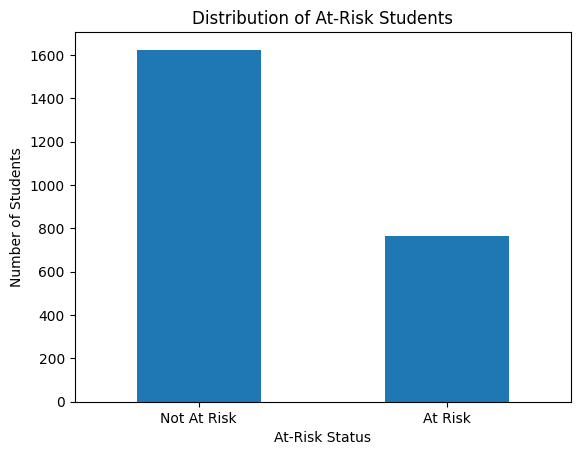

In [39]:
# Visualize at-risk distribution
df["AtRisk"].value_counts().plot(kind="bar")

plt.title("Distribution of At-Risk Students")
plt.xlabel("At-Risk Status")
plt.ylabel("Number of Students")
plt.xticks(ticks=[0, 1], labels=["Not At Risk", "At Risk"], rotation=0)
plt.show()

In [40]:
# Compare GPA for at-risk vs not at-risk students
df.groupby("AtRisk")["GPA"].mean()

AtRisk
0    2.841491
1    1.464722
Name: GPA, dtype: float64

In [41]:
# Compare absences for at-risk vs not at-risk students
df.groupby("AtRisk")["Absences"].mean()

AtRisk
0     6.361147
1    18.402462
Name: Absences, dtype: float64

In [42]:
# Compare study time for at-risk vs not at-risk students
df.groupby("AtRisk")["StudyTimeWeekly"].mean()

AtRisk
0    10.706635
1     9.330840
Name: StudyTimeWeekly, dtype: float64

## Exploratory Data Analysis Summary

The dataset contains 2,392 student records and 15 original variables related to student demographics, academic behavior, family support, extracurricular involvement, GPA, and grade classification. 

During exploratory data analysis, we examined the dataset structure, checked for missing values and duplicate records, reviewed summary statistics, and visualized the distribution of important variables such as GPA, absences, weekly study time, and grade class.

The GradeClass variable was used as the primary target variable because it categorizes students by academic performance. We also created an additional binary variable called AtRisk, where students with D or F grade classifications were labeled as at-risk. This allows the project to be framed around early identification of students who may need academic intervention.

Initial EDA focused on identifying patterns between academic outcomes and factors such as absences, study time, tutoring, parental support, extracurricular activities, and parental education. These variables will help guide feature selection and model development in later phases of the project.